In [79]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from rollingAvePlots_CL2026 import initialization


In [140]:
# Data
path = '/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/testing files/StrEpiFun-test-data/FINAL_TEST_DATA/COVID/italy-brazil/Results/Mice_mutations/'
prefix = 'mouse_muts'
group_name = 'country'
group = 'N501Y'
threshold = 1.2
with open('/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/testing files/StrEpiFun-test-data/FINAL_TEST_DATA/COVID/italy-brazil/Results/Mice_mutations/mouse_muts_N501Y1.2_heatmapmatrix.json', 'r') as file:
#with open( path + prefix +"_" + group +'_heatmapmatrix.json', 'r') as file:
    data = json.load(file)
heatmap = pd.DataFrame(data['z'], index=data['y'], columns=data['x'])

country2region, countryGrouping = initialization("inputs/UNSD — Methodology.csv")
country2region, countryGrouping 
if group_name == 'country':
    heatmap['Region'] = heatmap.index.map(country2region)
    heatmap = heatmap.sort_values(['Region'])
    heatmap = heatmap.drop(['Region'], axis=1)
else:
    heatmap = heatmap.sort_values([group_name])

lineplot = pd.read_csv('/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/testing files/StrEpiFun-test-data/FINAL_TEST_DATA/COVID/italy-brazil/Results/Mice_mutations/mouse_muts_RollingAvg_mutN501Y_t1.2.csv')
#lineplot = pd.read_csv(path+ prefix +'_RollingAvg_mut' + group + '_t' +str(threshold)+'.csv')
line_melted = lineplot.melt(id_vars='Date', value_vars=lineplot.columns[1:], 
                    var_name=group_name, value_name='Value')
line_melted


/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/strepifun-dev@5ccefb740d6_25062024/rollingAvePlots_CL2026.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  country2region[row[1]] = row[0]


,Date,country,Value
0,2020-01-01,Nigeria,NaN
1,2020-01-02,Nigeria,NaN
2,2020-01-03,Nigeria,NaN
3,2020-01-04,Nigeria,NaN
4,2020-01-05,Nigeria,NaN
...,...,...,...
3853,2021-09-30,Panama,NaN
3854,2021-10-01,Panama,NaN
3855,2021-10-02,Panama,NaN
3856,2021-10-03,Panama,NaN


In [150]:
len(heatmap_plot)

81

/var/folders/lz/nv2zvbvj4_564xncwcwld59r0000gp/T/ipykernel_74171/2247917872.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


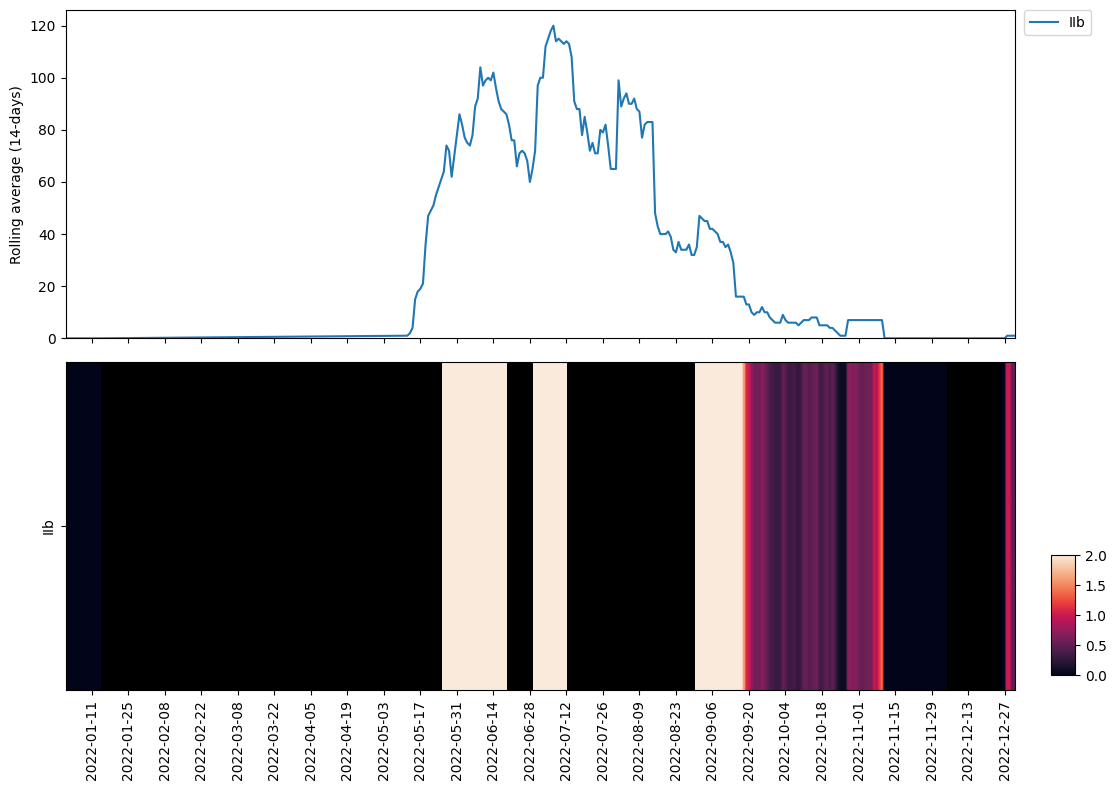

In [57]:
line_melted['Date'] = pd.to_datetime(line_melted['Date'])
heatmap.columns = pd.to_datetime(heatmap.columns)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True,gridspec_kw={'height_ratios': [1, 1]})

# lineplot
sns.lineplot(data=line_melted, x='Date', y='Value', hue=group_name, ax=axes[0])
axes[0].set_ylabel("Rolling average (14-days)")
axes[0].tick_params(labelsize=10)
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].set_ylim(bottom=0)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# heatmap with datetime axis
import matplotlib.dates as mdates
xmin = mdates.date2num(pd.to_datetime(heatmap.columns[0]))
xmax = mdates.date2num(pd.to_datetime(heatmap.columns[-1]))

im =  axes[1].imshow(heatmap.values, aspect='auto', vmin=0, vmax=2,cmap=sns.color_palette("rocket", as_cmap=True),
               extent=[xmin, xmax, len(heatmap), 0])
axes[1].xaxis_date()
axes[1].set_yticks(range(len(heatmap.index)))
axes[1].set_yticklabels(heatmap.index)
axes[1].set_facecolor("black")
axes[1].tick_params(labelsize=10, rotation=90)
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')
#cbar = fig.colorbar(im, ax=axes[1], orientation='horizontal', 
#                    location='bottom', shrink=0.3, anchor=(0, 0))
#cbar = fig.colorbar(im, ax=axes[1], orientation='vertical', 
#                    location='right', shrink=0.3, anchor=(0, 0))
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.15]) #eft, bottom, width, height
fig.colorbar(im, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.savefig('/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/manuscript_figures/' + prefix + group+ str(threshold) + '.svg', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/lz/nv2zvbvj4_564xncwcwld59r0000gp/T/ipykernel_79238/1854007376.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


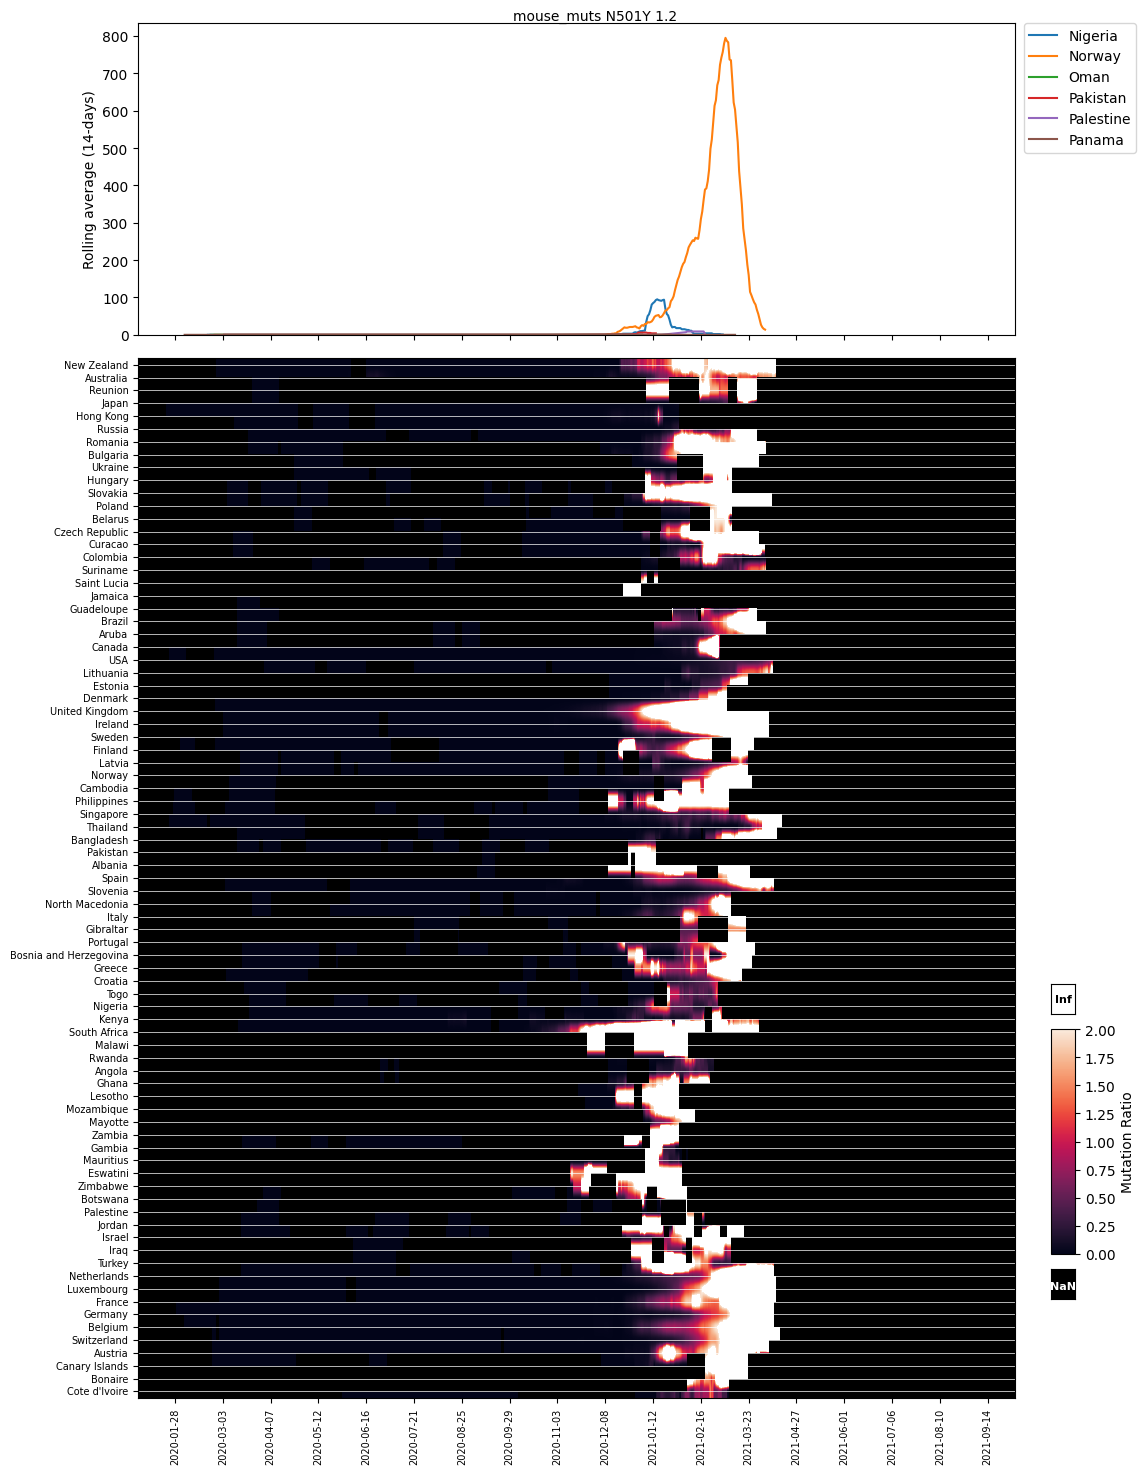

In [176]:
line_melted['Date'] = pd.to_datetime(line_melted['Date'])
heatmap.columns = pd.to_datetime(heatmap.columns)

axis_fontsize=7
title_fontsize =10 
interval=5

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 15), sharex=True,gridspec_kw={'height_ratios': [0.3, 1]})

# lineplot
sns.lineplot(data=line_melted, x='Date', y='Value', hue=group_name, ax=axes[0])
axes[0].set_ylabel("Rolling average (14-days)")
axes[0].tick_params(labelsize=10)
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=interval))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].set_ylim(bottom=0)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# heatmap with datetime axis
import matplotlib.dates as mdates
xmin = mdates.date2num(pd.to_datetime(heatmap.columns[0]))
xmax = mdates.date2num(pd.to_datetime(heatmap.columns[-1]))
heatmap_plot = heatmap.copy().astype(float)
heatmap_plot.replace([np.inf], 3, inplace=True)  # 3 is above vmax=2

cmap = sns.color_palette("rocket", as_cmap=True)
cmap.set_over('white')  # color for values above vmax

im =  axes[1].imshow(heatmap_plot.values, aspect='auto', vmin=0, vmax=2,cmap=cmap,
               extent=[xmin, xmax, len(heatmap), 0])
axes[1].xaxis_date()
axes[1].set_yticks(range(len(heatmap.index)))
axes[1].set_yticklabels(heatmap.index)
axes[1].set_facecolor("black")
axes[1].tick_params(labelsize=axis_fontsize)
axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')
#cbar = fig.colorbar(im, ax=axes[1], orientation='horizontal', 
#                    location='bottom', shrink=0.3, anchor=(0, 0))
#cbar = fig.colorbar(im, ax=axes[1], orientation='vertical', 
#                    location='right', shrink=0.3, anchor=(0, 0))
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.15]) #eft, bottom, width, height

axes[1].grid(which="major",  axis='y',color="w", linestyle='-', linewidth=0.5)

# remove extend and handle inf manually
cbar = fig.colorbar(im, cax=cbar_ax)  # no extend
ticks = [0, 0.25, 0.5, 0.75, 1.0]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

# add red square above colorbar
cbar_pos = cbar_ax.get_position()
inf_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y1 + 0.01, 
                        cbar_pos.width, cbar_pos.width])  # square
inf_ax.set_facecolor('white')
inf_ax.set_xticks([])
inf_ax.set_yticks([])
inf_ax.text(0.5, 0.5, 'Inf', ha='center', va='center',
            color='black', fontsize=8, fontweight='bold',
            transform=inf_ax.transAxes)
# NaN square below colorbar
nan_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01,
                        cbar_pos.width, cbar_pos.width])  # square
nan_ax.set_facecolor('black')
nan_ax.set_xticks([])
nan_ax.set_yticks([])
nan_ax.text(0.5, 0.6, 'NaN', ha='center', va='top',
            color='white', fontsize=8, fontweight='bold',
            transform=nan_ax.transAxes)

fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Mutation Ratio', fontsize=10)
plt.suptitle(prefix + " "+  group + " "+ str(threshold), size=title_fontsize)
plt.tight_layout()
plt.subplots_adjust(right=0.85)
#plt.savefig('/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/manuscript_figures/' + prefix + group + str(threshold) + '.svg', dpi=300, bbox_inches='tight')
plt.show()
